# E-VRPTW Dataset — Full Analysis

This notebook performs a **complete exploratory analysis** of the converted E-VRPTW dataset located in `dataset/evrptw_instances/`.

It is read-only: it does **not** modify any instance files. It loads every converted instance and studies:

1. Dataset overview & instance families
2. Instance-level structure (nodes / customers / stations)
3. Vehicle (energy) parameters
4. Customer demand
5. Time windows (detailed)
6. Service times
7. Spatial distribution (x–y)
8. Distance & energy matrices
9. Charging infrastructure
10. Reachability / feasibility pressure
11. Feature correlations
12. Instance-family comparison
13. Key findings

All distances are Euclidean in the x–y plane; no geographic map is used.

In [1]:
# --- Imports and path configuration ---
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Resolve the converted-instances directory regardless of launch location
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "dataset" and (NOTEBOOK_DIR / "dataset").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "dataset"

CONVERTED_DIR = NOTEBOOK_DIR / "evrptw_instances"
assert CONVERTED_DIR.exists(), f"Converted dataset not found at {CONVERTED_DIR}"

print(f"Analyzing converted dataset at: {CONVERTED_DIR}")

Analyzing converted dataset at: C:\Users\AYOUB\OneDrive - EMSI\Bureau\PHD_WORK\Transformer_MARL_EVRP\dataset\evrptw_instances


## 0. Load the entire converted dataset

We build three structures:
- `instances` — dict of per-instance loaded data (json + matrices + node table)
- `instance_df` — one row per instance (instance-level features)
- `nodes_df` — every node of every instance stacked, with an `instance` column

In [2]:
def classify_instance(name: str) -> dict:
    """Derive Solomon-style family attributes from an instance name.

    Examples: c101_21, r105_21, rc208C15, c101C5
    - family : 'C' (clustered), 'R' (random), 'RC' (random-clustered)
    - series : 1 or 2 (type-1 = tight windows / short horizon, type-2 = wide)
    - size_variant : 'full' (the _21 files) or 'reduced' (C5/C10/C15 subsets)
    """
    m = re.match(r"(rc|r|c)(\d)\d*", name, re.IGNORECASE)
    family = m.group(1).upper() if m else "?"
    series = int(m.group(2)) if m else -1
    if name.lower().endswith("_21"):
        size_variant = "full"
    elif re.search(r"C\d+$", name):
        size_variant = "reduced"
    else:
        size_variant = "other"
    return {"family": family, "series": series, "size_variant": size_variant}


instance_dirs = sorted(d for d in CONVERTED_DIR.iterdir() if d.is_dir())
print(f"Found {len(instance_dirs)} converted instances.")

Found 92 converted instances.


In [3]:
instances: dict[str, dict] = {}
instance_rows: list[dict] = []
node_frames: list[pd.DataFrame] = []

for d in instance_dirs:
    name = d.name
    data = json.loads((d / "evrp_instance.json").read_text(encoding="utf-8"))
    nodes_csv = pd.read_csv(d / "nodes.csv")
    mats = np.load(d / "matrices.npz")
    matrices = {k: mats[k] for k in mats.files}

    instances[name] = {"json": data, "nodes": nodes_csv, "matrices": matrices}

    meta = data["metadata"]
    vp = data["vehicle_parameters"]
    fam = classify_instance(name)

    customers = nodes_csv[nodes_csv["is_customer"]]
    stations = nodes_csv[nodes_csv["is_charging_station"]]

    dist = matrices["distance_matrix"]
    energy = matrices["energy_matrix"]
    # upper triangle (unique pairs) for distance statistics
    iu = np.triu_indices_from(dist, k=1)
    pair_dists = dist[iu]

    tw_width = (customers["due_time"] - customers["ready_time"]) if len(customers) else pd.Series(dtype=float)

    instance_rows.append({
        "instance": name,
        **fam,
        "num_nodes": len(nodes_csv),
        "num_customers": meta["num_customers"],
        "num_stations": meta["num_charging_stations"],
        "depot_has_charging": meta["depot_has_charging"],
        "battery_capacity": vp["battery_capacity"],
        "load_capacity": vp["load_capacity"],
        "energy_consumption_rate": vp["energy_consumption_rate"],
        "inverse_charging_rate": vp["inverse_charging_rate"],
        "speed": vp["speed"],
        "planning_horizon": meta["planning_horizon"],
        "total_demand": float(customers["demand"].sum()),
        "mean_demand": float(customers["demand"].mean()) if len(customers) else 0.0,
        "max_demand": float(customers["demand"].max()) if len(customers) else 0.0,
        "demand_to_capacity": float(customers["demand"].sum() / vp["load_capacity"]),
        "mean_tw_width": float(tw_width.mean()) if len(customers) else 0.0,
        "mean_service_time": float(customers["service_time"].mean()) if len(customers) else 0.0,
        "mean_pair_distance": float(pair_dists.mean()),
        "max_pair_distance": float(pair_dists.max()),
        "max_energy_pair": float(energy[iu].max()),
        "battery_vs_maxedge": float(vp["battery_capacity"] / energy[iu].max()),
        "stations_per_customer": meta["num_charging_stations"] / max(meta["num_customers"], 1),
    })

    nf = nodes_csv.copy()
    nf.insert(0, "instance", name)
    nf["family"] = fam["family"]
    nf["series"] = fam["series"]
    nf["size_variant"] = fam["size_variant"]
    node_frames.append(nf)

instance_df = pd.DataFrame(instance_rows).sort_values("instance").reset_index(drop=True)
nodes_df = pd.concat(node_frames, ignore_index=True)

print(f"Loaded {len(instance_df)} instances and {len(nodes_df)} total nodes.")
display(instance_df.head())

Loaded 92 instances and 7381 total nodes.


,instance,family,series,size_variant,num_nodes,num_customers,num_stations,depot_has_charging,battery_capacity,load_capacity,energy_consumption_rate,inverse_charging_rate,speed,planning_horizon,total_demand,mean_demand,max_demand,demand_to_capacity,mean_tw_width,mean_service_time,mean_pair_distance,max_pair_distance,max_energy_pair,battery_vs_maxedge,stations_per_customer
0,c101C10,C,1,reduced,16,10,5,True,77.75,200.0,1.0,3.47,1.0,1236.0,200.0,20.000000,40.0,1.00,60.800000,90.0,39.646413,77.878110,77.878110,0.998355,0.500000
1,c101C5,C,1,reduced,9,5,3,True,77.75,200.0,1.0,3.47,1.0,1236.0,90.0,18.000000,30.0,0.45,58.400000,90.0,35.199309,61.131007,61.131007,1.271859,0.600000
2,c101_21,C,1,full,122,100,21,True,79.69,200.0,1.0,3.39,1.0,1236.0,1810.0,18.100000,50.0,9.05,62.710000,90.0,41.219553,105.309069,105.309069,0.756725,0.210000
3,c102_21,C,1,full,122,100,21,True,79.69,200.0,1.0,3.39,1.0,1236.0,1810.0,18.100000,50.0,9.05,327.570000,90.0,41.219553,105.309069,105.309069,0.756725,0.210000
4,c103C15,C,1,reduced,21,15,5,True,77.75,200.0,1.0,3.47,1.0,1236.0,260.0,17.333333,40.0,1.30,557.266667,90.0,36.587691,72.622311,72.622311,1.070608,0.333333


## 1. Dataset overview & instance families

Solomon-style benchmark families:
- **C** = clustered customers
- **R** = randomly placed customers
- **RC** = mix of random + clustered

Series **1** = short scheduling horizon / tight time windows; series **2** = long horizon / wide windows.
Size variant: **full** (the `_21` files, ~100 customers) vs **reduced** (`C5`/`C10`/`C15` subsets).

Total instances: 92
Total nodes across dataset: 7381
  depots  : 92
  customers: 5960
  stations : 1329



count  avg_customers  avg_stations
family series size_variant                                    
C      1      full              9          100.0          21.0
              reduced           6           10.0           3.7
       2      full              8          100.0          21.0
              reduced           6           10.0           4.0
R      1      full             12          100.0          21.0
              reduced           6           10.0           4.5
       2      full             11          100.0          21.0
              reduced           6           10.0           4.5
RC     1      full              8          100.0          21.0
              reduced           6           10.0           4.3
       2      full              8          100.0          21.0
              reduced           6           10.0           4.5

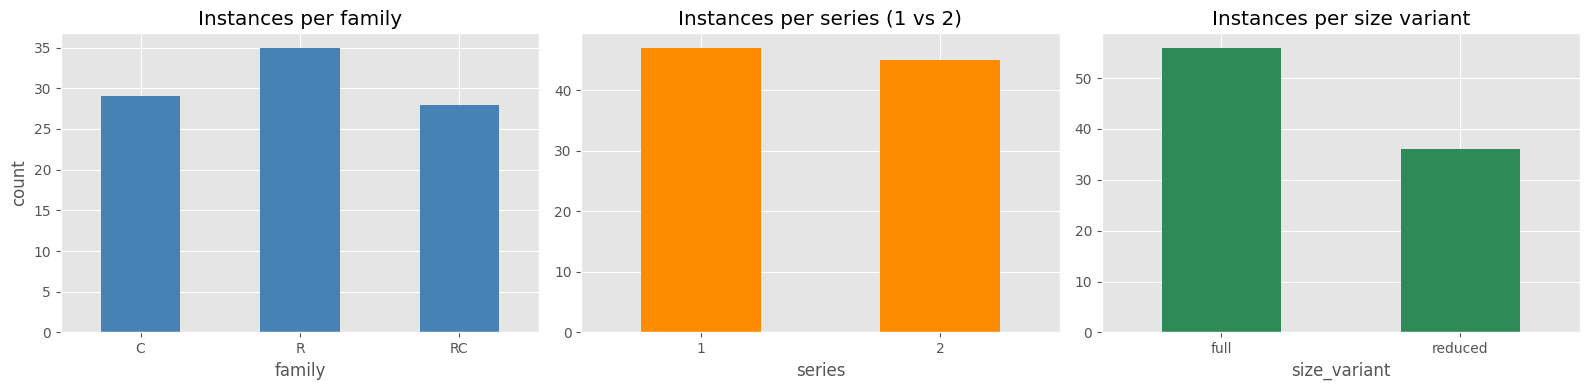

In [4]:
print("Total instances:", len(instance_df))
print("Total nodes across dataset:", len(nodes_df))
print("  depots  :", int(nodes_df['is_depot'].sum()))
print("  customers:", int(nodes_df['is_customer'].sum()))
print("  stations :", int(nodes_df['is_charging_station'].sum()))
print()

overview = (
    instance_df
    .groupby(["family", "series", "size_variant"])
    .agg(count=("instance", "size"),
         avg_customers=("num_customers", "mean"),
         avg_stations=("num_stations", "mean"))
    .round(1)
)
display(overview)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
instance_df["family"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Instances per family")
axes[0].set_ylabel("count")
instance_df["series"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Instances per series (1 vs 2)")
instance_df["size_variant"].value_counts().plot(kind="bar", ax=axes[2], color="seagreen")
axes[2].set_title("Instances per size variant")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 2. Instance-level structure

How big are the instances, and how many customers / charging stations do they contain?

,num_nodes,num_customers,num_stations,stations_per_customer
count,92.00,92.00,92.00,92.00
mean,80.23,64.78,14.45,0.31
std,52.48,44.24,8.25,0.17
min,8.00,5.00,2.00,0.20
25%,16.00,10.00,4.75,0.21
50%,122.00,100.00,21.00,0.21
75%,122.00,100.00,21.00,0.40
max,122.00,100.00,21.00,0.80


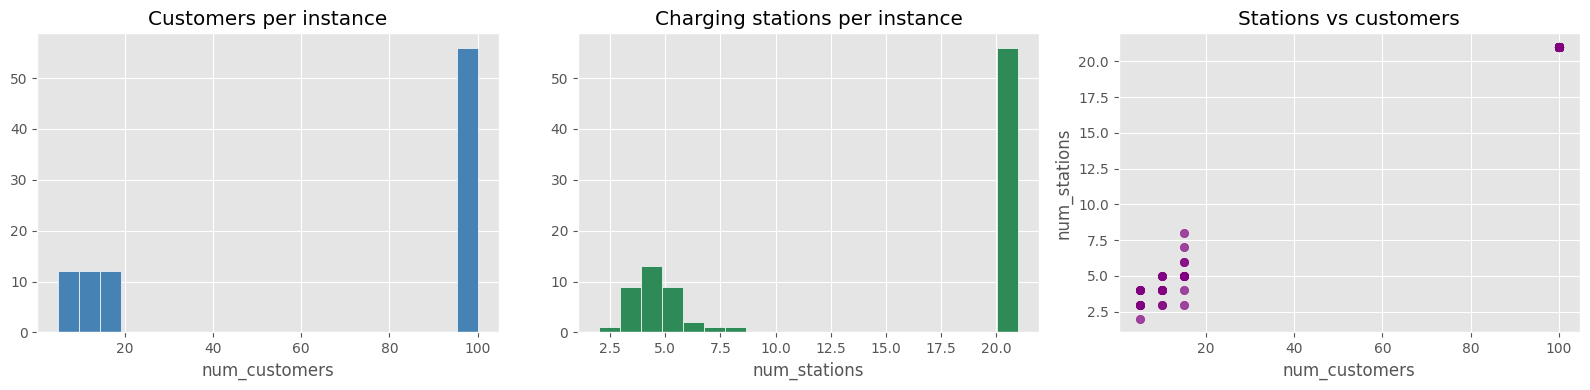

In [5]:
display(instance_df[["num_nodes", "num_customers", "num_stations", "stations_per_customer"]].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(instance_df["num_customers"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Customers per instance")
axes[0].set_xlabel("num_customers")

axes[1].hist(instance_df["num_stations"], bins=20, color="seagreen", edgecolor="white")
axes[1].set_title("Charging stations per instance")
axes[1].set_xlabel("num_stations")

axes[2].scatter(instance_df["num_customers"], instance_df["num_stations"], alpha=0.7, c="purple")
axes[2].set_title("Stations vs customers")
axes[2].set_xlabel("num_customers")
axes[2].set_ylabel("num_stations")
plt.tight_layout()
plt.show()

## 3. Vehicle (energy) parameters

Converted EVRP parameters:
- `battery_capacity` (was fuel tank capacity Q)
- `load_capacity` (C)
- `energy_consumption_rate` (r)
- `inverse_charging_rate` (g)
- `speed` (v)

,battery_capacity,load_capacity,energy_consumption_rate,inverse_charging_rate,speed
count,92.000,92.000,92.0,92.000,92.0
mean,105.242,545.652,1.0,1.222,1.0
std,58.354,368.368,0.0,1.331,0.0
min,60.630,200.000,1.0,0.110,1.0
25%,67.143,200.000,1.0,0.380,1.0
50%,77.750,200.000,1.0,0.475,1.0
75%,117.865,1000.000,1.0,2.290,1.0
max,273.130,1000.000,1.0,3.470,1.0


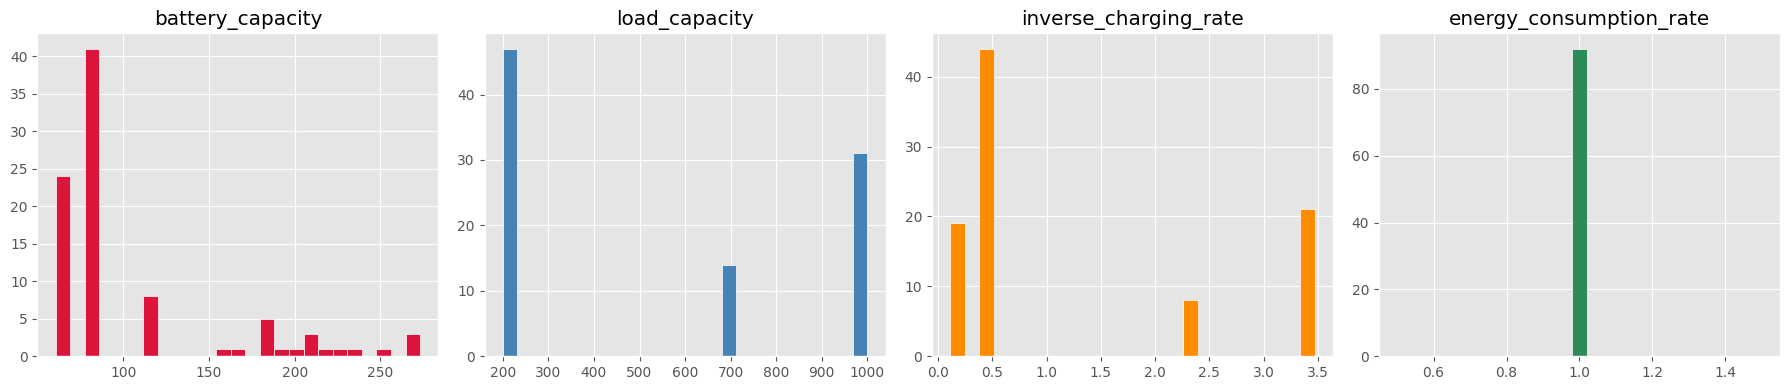

battery_capacity: ranges 60.630 .. 273.130
load_capacity: constant/few values -> [np.float64(200.0), np.float64(700.0), np.float64(1000.0)]
energy_consumption_rate: constant/few values -> [np.float64(1.0)]
inverse_charging_rate: ranges 0.110 .. 3.470
speed: constant/few values -> [np.float64(1.0)]


In [6]:
param_cols = ["battery_capacity", "load_capacity", "energy_consumption_rate", "inverse_charging_rate", "speed"]
display(instance_df[param_cols].describe().round(3))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(instance_df["battery_capacity"], bins=25, color="crimson", edgecolor="white")
axes[0].set_title("battery_capacity")
axes[1].hist(instance_df["load_capacity"], bins=25, color="steelblue", edgecolor="white")
axes[1].set_title("load_capacity")
axes[2].hist(instance_df["inverse_charging_rate"], bins=25, color="darkorange", edgecolor="white")
axes[2].set_title("inverse_charging_rate")
axes[3].hist(instance_df["energy_consumption_rate"], bins=25, color="seagreen", edgecolor="white")
axes[3].set_title("energy_consumption_rate")
plt.tight_layout()
plt.show()

for col in param_cols:
    vals = instance_df[col].unique()
    if len(vals) <= 6:
        print(f"{col}: constant/few values -> {sorted(vals)}")
    else:
        print(f"{col}: ranges {instance_df[col].min():.3f} .. {instance_df[col].max():.3f}")

## 4. Customer demand

Demand drives the load-capacity constraint. We look at the pooled customer demand across the whole dataset and at the per-instance demand/capacity pressure.

Pooled customer demand statistics:


,count,mean,std,min,25%,50%,75%,max
demand,5960.0,16.41,9.61,1.0,10.0,14.0,20.0,50.0


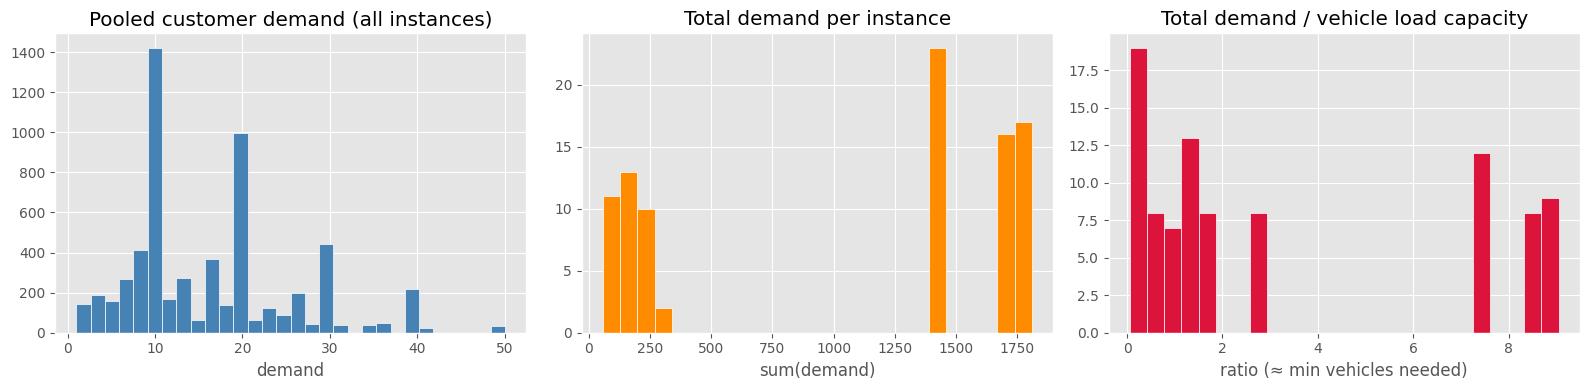

Demand/capacity ratio summary (higher => more vehicles / tighter load):


,count,mean,std,min,25%,50%,75%,max
demand_to_capacity,92.0,3.33,3.42,0.06,0.66,1.46,7.29,9.05


In [7]:
cust_nodes = nodes_df[nodes_df["is_customer"]]
print("Pooled customer demand statistics:")
display(cust_nodes["demand"].describe().round(2).to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(cust_nodes["demand"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Pooled customer demand (all instances)")
axes[0].set_xlabel("demand")

axes[1].hist(instance_df["total_demand"], bins=25, color="darkorange", edgecolor="white")
axes[1].set_title("Total demand per instance")
axes[1].set_xlabel("sum(demand)")

axes[2].hist(instance_df["demand_to_capacity"], bins=25, color="crimson", edgecolor="white")
axes[2].set_title("Total demand / vehicle load capacity")
axes[2].set_xlabel("ratio (≈ min vehicles needed)")
plt.tight_layout()
plt.show()

print("Demand/capacity ratio summary (higher => more vehicles / tighter load):")
display(instance_df["demand_to_capacity"].describe().round(2).to_frame().T)

## 5. Time windows — detailed analysis

Each customer has a hard time window `[ready_time, due_time]`:

- **Ready time** — earliest time service may start (early arrival ⇒ waiting).
- **Due time** — latest time the vehicle may **arrive** (lateness is penalised in the RL objective).
- **Window width** = `due_time − ready_time` — slack for routing and sequencing.

Solomon convention in this dataset:

| Series | Horizon (typical) | Window character |
|--------|-------------------|------------------|
| **1** (e.g. C1xx, R1xx) | ~1236 | **Tight** — especially R1/RC1 (width ≈ 80–90) |
| **2** (e.g. C2xx, R2xx) | ~3390 | **Wide** — much larger windows |

The subsections below quantify:

1. **Distribution** — ready / due / width across all customers  
2. **Depot-direct slack** — can a vehicle leaving the depot at `t=0` reach each customer on time?  
3. **Temporal overlap** — how many customer pairs have overlapping windows (competition for the same time band)?  
4. **Chaining pressure** — fraction of ordered pairs `(i→j)` that are time-feasible if `i` is served first from a zero-start depot route  
5. **Instance difficulty scores** — aggregated TW metrics per instance / family  
6. **Timeline visuals** — Gantt-style plots for representative instances  
7. **Training implications** — which classes are TW-limited vs coverage-limited

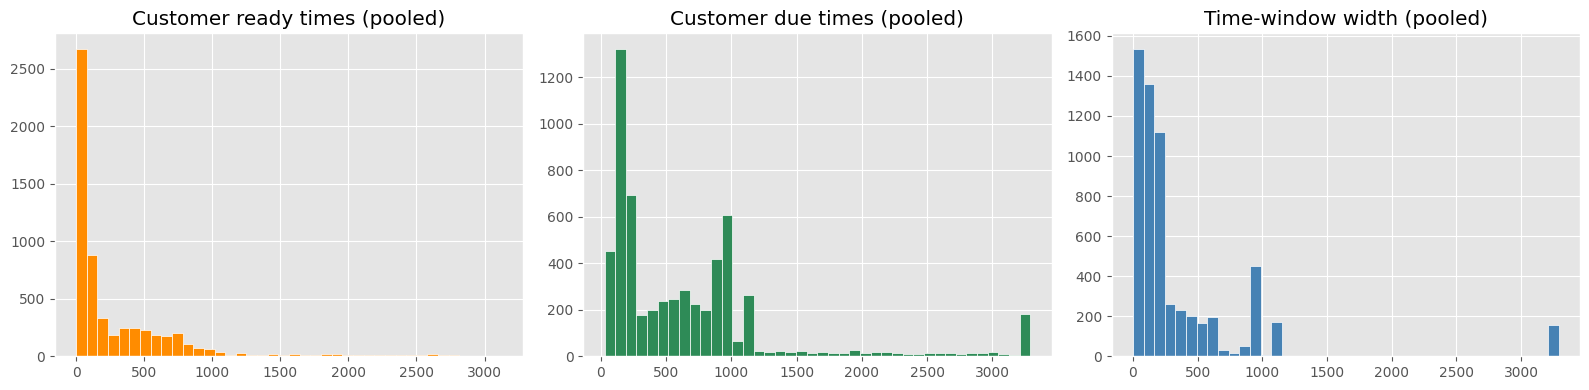

Mean time-window width by family x series:


series,1,2
family,,
C,368.7,809.2
R,81.7,460.8
RC,88.7,394.6


In [8]:
# --- 5.0 Pooled distributions (all customers) ---
cust = nodes_df[nodes_df["is_customer"]].copy()
cust["tw_width"] = cust["due_time"] - cust["ready_time"]
cust["tw_midpoint"] = 0.5 * (cust["ready_time"] + cust["due_time"])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(cust["ready_time"], bins=50, color="darkorange", edgecolor="white")
axes[0, 0].set_title("Ready times (pooled)")
axes[0, 0].set_xlabel("ready_time")

axes[0, 1].hist(cust["due_time"], bins=50, color="seagreen", edgecolor="white")
axes[0, 1].set_title("Due times (pooled)")
axes[0, 1].set_xlabel("due_time")

axes[0, 2].hist(cust["tw_width"], bins=50, color="steelblue", edgecolor="white")
axes[0, 2].set_title("Window width (pooled)")
axes[0, 2].set_xlabel("due − ready")

# Width by family (boxplot)
family_order = ["C", "R", "RC"]
cust.boxplot(column="tw_width", by="family", ax=axes[1, 0])
axes[1, 0].set_title("Window width by family")
axes[1, 0].set_xlabel("family")
plt.suptitle("")

# Width by series
cust.boxplot(column="tw_width", by="series", ax=axes[1, 1])
axes[1, 1].set_title("Window width by series (1=tight, 2=wide)")
axes[1, 1].set_xlabel("series")
plt.suptitle("")

# Width by family × series
tw_pivot = cust.groupby(["family", "series"])["tw_width"].mean().unstack("series")
tw_pivot.loc[family_order].plot(kind="bar", ax=axes[1, 2], rot=0)
axes[1, 2].set_title("Mean window width: family × series")
axes[1, 2].set_ylabel("mean width")
axes[1, 2].legend(title="series")
plt.tight_layout()
plt.show()

print("Customer-level time-window summary (pooled):")
display(cust[["ready_time", "due_time", "tw_width", "service_time"]].describe().round(2))

tw_by_series = (
    instance_df.groupby(["family", "series"])["mean_tw_width"].mean().round(1).unstack("series")
)
print("\nMean time-window width by family × series (instance means):")
display(tw_by_series)

### 5.1 Customer-level enriched metrics

For every customer in every instance we compute:

| Metric | Meaning |
|--------|---------|
| `tw_width` | `due − ready` |
| `tw_width_ratio` | width / planning horizon |
| `service_over_tw` | service time as fraction of window (high ⇒ little routing slack inside window) |
| `depot_travel_time` | travel time depot → customer |
| `depot_slack_late` | `due − depot_travel` — latest time the depot may release the vehicle for a **direct** visit |
| `depot_slack_early` | `ready − depot_travel` — slack before waiting if leaving depot at `t=0` |
| `direct_from_depot_feasible` | `depot_travel ≤ due` (same rule as the env mask `time_window_late`) |
| `tight_tw` / `very_tight_tw` | width `< 30` / `< 15` (Solomon type-1 scale) |

In [ ]:
# --- 5.1 Build enriched per-customer TW table ---

def build_tw_enriched(instances: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (customer_tw_df, instance_tw_df) with detailed time-window metrics."""
    tw_rows: list[dict] = []
    inst_rows: list[dict] = []

    for name, payload in instances.items():
        data = payload["json"]
        nodes = payload["nodes"]
        travel = payload["matrices"]["travel_time_matrix"]
        depot = int(data["index_sets"]["depot_index"])
        horizon = float(data["metadata"]["planning_horizon"])
        fam = classify_instance(name)
        customers = nodes[nodes["is_customer"]].copy()
        if customers.empty:
            continue

        idx = customers["id"].astype(int).values
        ready = customers["ready_time"].astype(float).values
        due = customers["due_time"].astype(float).values
        service = customers["service_time"].astype(float).values

        tw_width = due - ready
        depot_tt = travel[depot, idx]
        arrival0 = depot_tt
        service_start0 = np.maximum(arrival0, ready)
        finish0 = service_start0 + service
        direct_feasible = arrival0 <= due + 1e-6
        direct_late = np.maximum(0.0, arrival0 - due)

        for k in range(len(customers)):
            base = customers.iloc[k].to_dict()
            w = float(tw_width[k])
            base.update({
                "instance": name,
                **fam,
                "planning_horizon": horizon,
                "tw_width": w,
                "tw_midpoint": 0.5 * (ready[k] + due[k]),
                "tw_width_ratio": w / horizon if horizon else np.nan,
                "ready_ratio": ready[k] / horizon if horizon else np.nan,
                "due_ratio": due[k] / horizon if horizon else np.nan,
                "service_over_tw": service[k] / w if w > 1e-6 else np.nan,
                "depot_travel_time": float(depot_tt[k]),
                "depot_slack_late": float(due[k] - depot_tt[k]),
                "depot_slack_early": float(ready[k] - depot_tt[k]),
                "wait_if_leave_depot_at_zero": float(max(0.0, ready[k] - arrival0[k])),
                "finish_if_leave_depot_at_zero": float(finish0[k]),
                "direct_from_depot_feasible": bool(direct_feasible[k]),
                "direct_late_by": float(direct_late[k]),
                "tight_tw": w < 30,
                "very_tight_tw": w < 15,
            })
            tw_rows.append(base)

        n = len(idx)
        overlap_pairs = 0
        pair_total = n * (n - 1) // 2
        for a in range(n):
            for b in range(a + 1, n):
                if ready[a] <= due[b] and ready[b] <= due[a]:
                    overlap_pairs += 1

        chain_ok = chain_total = 0
        for a in range(n):
            for b in range(n):
                if a == b:
                    continue
                chain_total += 1
                arr_b = finish0[a] + travel[idx[a], idx[b]]
                if arr_b <= due[b] + 1e-6:
                    chain_ok += 1

        inst_rows.append({
            "instance": name,
            **fam,
            "planning_horizon": horizon,
            "num_customers": n,
            "mean_tw_width": float(tw_width.mean()),
            "std_tw_width": float(tw_width.std()),
            "min_tw_width": float(tw_width.min()),
            "median_tw_width": float(np.median(tw_width)),
            "max_tw_width": float(tw_width.max()),
            "pct_tight_tw": float((tw_width < 30).mean()),
            "pct_very_tight_tw": float((tw_width < 15).mean()),
            "pct_direct_infeasible": float((~direct_feasible).mean()),
            "mean_depot_slack_late": float((due - depot_tt).mean()),
            "min_depot_slack_late": float((due - depot_tt).min()),
            "mean_service_over_tw": float(np.mean(service / np.maximum(tw_width, 1e-6))),
            "temporal_span": float(due.max() - ready.min()),
            "horizon_utilization": float((due.max() - ready.min()) / horizon) if horizon else np.nan,
            "earliest_ready": float(ready.min()),
            "latest_due": float(due.max()),
            "overlap_pair_density": float(overlap_pairs / pair_total) if pair_total else 0.0,
            "chain_feasible_rate": float(chain_ok / chain_total) if chain_total else 1.0,
        })

    return pd.DataFrame(tw_rows), pd.DataFrame(inst_rows)


tw_df, tw_instance_df = build_tw_enriched(instances)
print(f"Enriched TW table: {len(tw_df)} customers across {len(tw_instance_df)} instances")

metric_cols = [
    "tw_width", "tw_width_ratio", "service_over_tw",
    "depot_travel_time", "depot_slack_late", "depot_slack_early",
]
print("\nEnriched metrics (pooled describe):")
display(tw_df[metric_cols].describe().round(3))

print("\nTight-window prevalence by family × series:")
tight_tbl = (
    tw_df.groupby(["family", "series"])
    .agg(
        customers=("tw_width", "count"),
        mean_width=("tw_width", "mean"),
        pct_tight=("tight_tw", "mean"),
        pct_very_tight=("very_tight_tw", "mean"),
        pct_direct_infeasible=("direct_from_depot_feasible", lambda s: 1 - s.mean()),
        mean_depot_slack_late=("depot_slack_late", "mean"),
    )
    .round(3)
)
display(tight_tbl)

### 5.2 Depot-direct slack & service-time pressure

If an EV leaves the depot at `t = 0` and drives directly to customer `j`:

- **Arrival** = `depot_travel_time[j]`
- **Feasible** iff `arrival ≤ due_time` (matches the environment mask)
- **Waiting** = `max(0, ready − arrival)` when arriving early

We also compare **travel time vs window width** — when `depot_travel > tw_width`, even a dedicated trip barely fits inside the window.

In [ ]:
# --- 5.2 Depot slack visualisations ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Travel vs window width
axes[0, 0].scatter(
    tw_df["tw_width"], tw_df["depot_travel_time"], c=tw_df["series"].map({1: "#e45756", 2: "#4c78a8"}),
    alpha=0.25, s=12, edgecolors="none",
)
axes[0, 0].plot([0, tw_df["tw_width"].max()], [0, tw_df["tw_width"].max()], "k--", lw=1, label="travel = width")
axes[0, 0].set_xlabel("time-window width")
axes[0, 0].set_ylabel("depot travel time")
axes[0, 0].set_title("Depot travel vs TW width (colour = series)")
axes[0, 0].legend()

# Depot slack late distribution by family
for fam, color in zip(["C", "R", "RC"], ["#54a24b", "#eeca3b", "#b279a2"]):
    sub = tw_df[tw_df["family"] == fam]["depot_slack_late"]
    axes[0, 1].hist(sub, bins=40, alpha=0.45, label=fam, color=color, edgecolor="white")
axes[0, 1].axvline(0, color="black", ls="--", lw=1)
axes[0, 1].set_title("Depot slack late (due − travel); negative = direct infeasible")
axes[0, 1].set_xlabel("depot_slack_late")
axes[0, 1].legend()

# Service time as fraction of window
axes[1, 0].hist(tw_df["service_over_tw"].clip(0, 1.5), bins=40, color="teal", edgecolor="white")
axes[1, 0].set_title("Service time / window width")
axes[1, 0].set_xlabel("service_over_tw")

# Direct infeasible rate by instance family×series
direct_rate = (
    tw_df.groupby(["family", "series"])["direct_from_depot_feasible"]
    .apply(lambda s: 1 - s.mean())
    .unstack("series")
)
direct_rate.loc[["C", "R", "RC"]].plot(kind="bar", ax=axes[1, 1], rot=0)
axes[1, 1].set_title("Share of customers NOT directly reachable from depot at t=0")
axes[1, 1].set_ylabel("fraction infeasible")
axes[1, 1].legend(title="series")
plt.tight_layout()
plt.show()

print("Customers where depot travel exceeds window width (routing barely fits one leg):")
mask = tw_df["depot_travel_time"] > tw_df["tw_width"]
print(f"  count = {mask.sum()} / {len(tw_df)} ({100*mask.mean():.2f}%)")
display(
    tw_df.loc[mask, ["instance", "family", "series", "string_id", "tw_width", "depot_travel_time", "depot_slack_late"]]
    .head(12)
)

### 5.3 Temporal overlap & pairwise chaining

**Overlap:** customers `i` and `j` overlap if their windows intersect — they compete for the same schedule band.

**Chaining rate:** among all ordered pairs `(i → j)`, the fraction where serving `i` first (from a route starting at the depot at `t=0`) still allows a on-time arrival at `j`. Low chaining rates mean sequencing is highly constrained (typical for tight R1 / RC1 instances).

In [ ]:
# --- 5.3 Instance-level overlap & chaining ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fam, color in zip(["C", "R", "RC"], ["#54a24b", "#eeca3b", "#b279a2"]):
    sub = tw_instance_df[tw_instance_df["family"] == fam]
    axes[0].scatter(sub["overlap_pair_density"], sub["chain_feasible_rate"], c=color, label=fam, alpha=0.7)
axes[0].set_xlabel("overlap pair density")
axes[0].set_ylabel("chain feasible rate")
axes[0].set_title("Per instance: overlap vs chaining feasibility")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

chain_pivot = tw_instance_df.pivot_table(
    index="family", columns="series", values="chain_feasible_rate", aggfunc="mean"
)
chain_pivot.loc[["C", "R", "RC"]].plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Mean chain-feasible rate by family × series")
axes[1].set_ylabel("chain_feasible_rate")
axes[1].legend(title="series")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Instance TW difficulty summary (family × series means):")
tw_family_summary = (
    tw_instance_df.groupby(["family", "series"])
    .agg(
        instances=("instance", "count"),
        mean_width=("mean_tw_width", "mean"),
        pct_tight=("pct_tight_tw", "mean"),
        pct_direct_infeas=("pct_direct_infeasible", "mean"),
        overlap=("overlap_pair_density", "mean"),
        chain_rate=("chain_feasible_rate", "mean"),
        horizon_util=("horizon_utilization", "mean"),
    )
    .round(3)
)
display(tw_family_summary)

print("\nHardest instances by chain_feasible_rate (lowest = most sequencing pressure):")
display(
    tw_instance_df.nsmallest(10, "chain_feasible_rate")[
        ["instance", "family", "series", "size_variant", "chain_feasible_rate",
         "overlap_pair_density", "mean_tw_width", "pct_tight_tw"]
    ].round(3)
)

### 5.4 Timeline (Gantt) plots — representative instances

Each bar is one customer window `[ready, due]`. Colour = window width (narrower = tighter). We pick one **full** (`_21`) instance per family for series 1 and series 2.

In [ ]:
# --- 5.4 Gantt-style time-window timelines ---

def pick_full_example(family: str, series: int) -> str | None:
    cands = instance_df[
        (instance_df["family"] == family)
        & (instance_df["series"] == series)
        & (instance_df["size_variant"] == "full")
    ]["instance"].tolist()
    return cands[0] if cands else None


def plot_tw_timeline(instance_name: str, ax, max_customers: int = 60):
    sub = tw_df[tw_df["instance"] == instance_name].sort_values("ready_time")
    if len(sub) > max_customers:
        sub = sub.iloc[:max_customers]
    horizon = sub["planning_horizon"].iloc[0]
    y = np.arange(len(sub))
    widths = sub["tw_width"].values
    colors = sub["ready_time"].values
    bars = ax.barh(
        y, widths, left=sub["ready_time"].values, height=0.8,
        color=plt.cm.plasma(sub["tw_width"] / max(sub["tw_width"].max(), 1)),
        edgecolor="none",
    )
    for yi, (_, row) in enumerate(sub.iterrows()):
        ax.plot([row["ready_time"], row["due_time"]], [yi, yi], color="black", lw=0.4, alpha=0.5)
        if not row["direct_from_depot_feasible"]:
            ax.scatter([row["due_time"]], [yi], c="red", s=8, zorder=3)
    ax.set_xlim(0, horizon * 1.02)
    ax.set_xlabel("time")
    ax.set_ylabel("customer (sorted by ready)")
    meta = classify_instance(instance_name)
    ax.set_title(
        f"{instance_name} | family={meta['family']} series={meta['series']} | "
        f"horizon={horizon:.0f} | n={len(sub)}"
    )
    ax.invert_yaxis()


fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
for row, series in enumerate([1, 2]):
    for col, fam in enumerate(["C", "R", "RC"]):
        name = pick_full_example(fam, series)
        ax = axes[row, col]
        if name is None:
            ax.set_title(f"No full instance for {fam}{series}")
            ax.axis("off")
            continue
        plot_tw_timeline(name, ax)
fig.suptitle("Customer time windows (bar = [ready, due]; red dot = direct-from-depot infeasible)", y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Per-instance deep dive (single instance)

Pick any instance name below to inspect **every customer row** sorted by ready time, plus a histogram of window widths for that instance only.

In [ ]:
# --- 5.5 Single-instance drill-down (edit INSTANCE_NAME to explore) ---

INSTANCE_NAME = pick_full_example("C", 1) or instance_df["instance"].iloc[0]
one = tw_df[tw_df["instance"] == INSTANCE_NAME].sort_values("ready_time").copy()
inst_meta = tw_instance_df[tw_instance_df["instance"] == INSTANCE_NAME].iloc[0]

print(f"Drill-down: {INSTANCE_NAME}")
display(inst_meta.to_frame("value").round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(one["tw_width"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title(f"Window widths — {INSTANCE_NAME}")
axes[0].set_xlabel("tw_width")

axes[1].scatter(one["ready_time"], one["due_time"], c=one["depot_slack_late"], cmap="RdYlGn", s=40)
axes[1].set_xlabel("ready_time")
axes[1].set_ylabel("due_time")
axes[1].set_title("Ready vs due (colour = depot_slack_late)")
plt.tight_layout()
plt.show()

cols = [
    "string_id", "ready_time", "due_time", "tw_width", "service_time", "service_over_tw",
    "depot_travel_time", "depot_slack_late", "depot_slack_early",
    "direct_from_depot_feasible", "wait_if_leave_depot_at_zero",
]
print("All customers (sorted by ready_time):")
display(one[cols].round(2))

### 5.6 Time-window findings for RL training

Summary of what the metrics above imply for the Transformer MARL curriculum:

1. **Series 1 vs 2** — Series **1** instances (horizon ≈ 1236) have much tighter windows, especially **R1** and **RC1** (mean width ≈ 80–90). Series **2** is horizon-relaxed (≈ 3390) with widths often 400–800+.
2. **C1 is the easiest TW-wise** — clustered C1 windows are wide (~370 mean width) with high chain-feasible rates; good starting point for curriculum.
3. **R1 / RC1 are sequencing-limited** — low chain rates and high overlap density; failures are often **unserved customers** rather than explicit TW violations when masks are enforced.
4. **Depot-direct slack** — most customers are directly reachable from the depot at `t=0`; TW pressure appears when **chaining** multiple customers, charging detours, and multi-EV coordination are added.
5. **Reduced instances (C5/C10/C15)** inherit the same TW structure as their parent series — they reduce **count** pressure, not per-customer tightness.

Use `tw_instance_df` for ranking instances by `chain_feasible_rate`, `pct_tight_tw`, or `pct_direct_infeasible` when designing curriculum stages.

## 6. Service times

Time spent at each customer for loading. Stations and depot have zero service time.

Service time by node type:


,count,mean,std,min,25%,50%,75%,max
node_type,,,,,,,,
charging_station,1329.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
customer,5960.0,34.43,36.85,10.0,10.0,10.0,90.0,90.0
depot,92.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


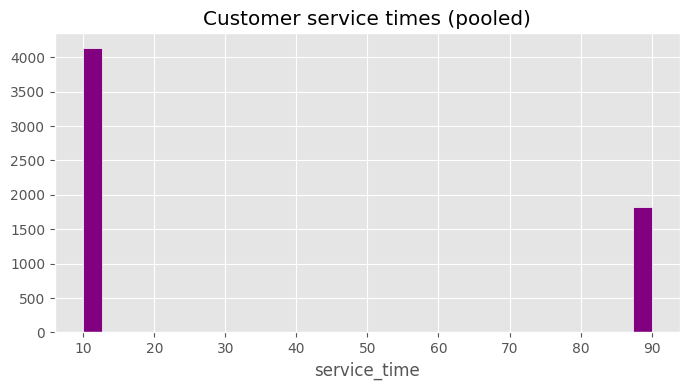

In [9]:
print("Service time by node type:")
display(nodes_df.groupby("node_type")["service_time"].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cust_nodes["service_time"], bins=30, color="purple", edgecolor="white")
ax.set_title("Customer service times (pooled)")
ax.set_xlabel("service_time")
plt.tight_layout()
plt.show()

## 7. Spatial distribution (x–y)

We plot representative instances from each family to show the clustered (C), random (R), and mixed (RC) layouts, distinguishing depot / customers / charging stations.

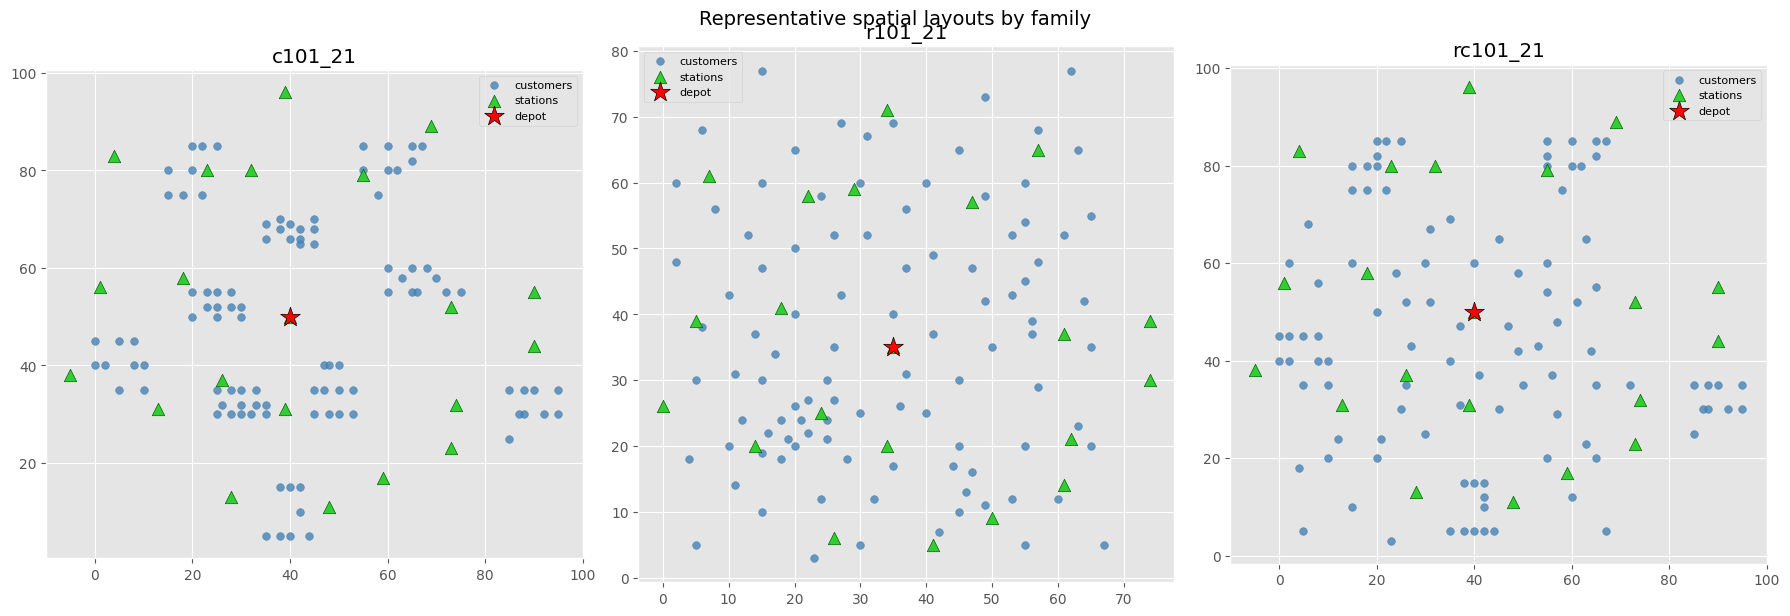

In [10]:
def pick_example(family: str) -> str:
    """Pick a full-size (~100 customer) instance from a family if available."""
    cand = instance_df[(instance_df["family"] == family) & (instance_df["size_variant"] == "full")]
    if cand.empty:
        cand = instance_df[instance_df["family"] == family]
    return cand.sort_values("num_customers", ascending=False).iloc[0]["instance"]

examples = [pick_example(f) for f in ["C", "R", "RC"] if f in instance_df["family"].values]

fig, axes = plt.subplots(1, len(examples), figsize=(6 * len(examples), 6))
if len(examples) == 1:
    axes = [axes]
for ax, name in zip(axes, examples):
    nf = instances[name]["nodes"]
    cu = nf[nf["is_customer"]]
    st = nf[nf["is_charging_station"]]
    de = nf[nf["is_depot"]]
    ax.scatter(cu["x"], cu["y"], s=30, c="steelblue", alpha=0.8, label="customers", zorder=2)
    ax.scatter(st["x"], st["y"], s=80, marker="^", c="limegreen", edgecolors="darkgreen", label="stations", zorder=3)
    ax.scatter(de["x"], de["y"], s=220, marker="*", c="red", edgecolors="black", label="depot", zorder=4)
    ax.set_title(f"{name}")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
plt.suptitle("Representative spatial layouts by family", fontsize=14)
plt.tight_layout()
plt.show()

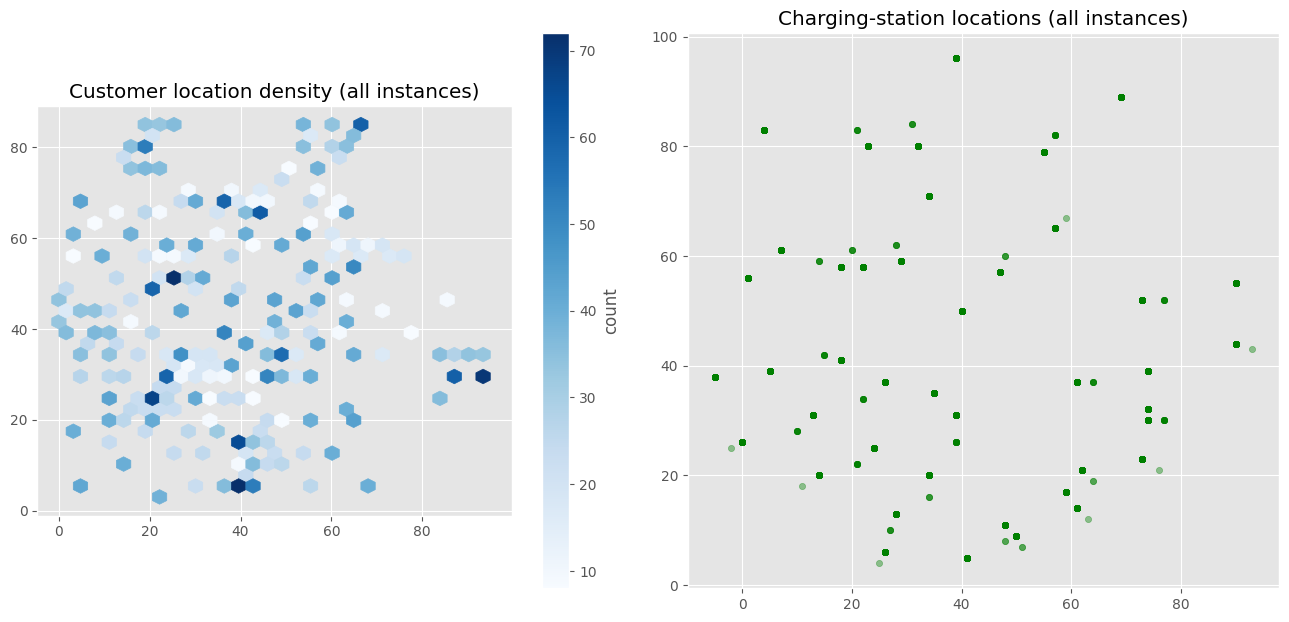

In [11]:
# Aggregate spatial footprint: where do customers vs stations sit across all instances?
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
all_cust = nodes_df[nodes_df["is_customer"]]
all_stat = nodes_df[nodes_df["is_charging_station"]]

hb = axes[0].hexbin(all_cust["x"], all_cust["y"], gridsize=30, cmap="Blues", mincnt=1)
axes[0].set_title("Customer location density (all instances)")
axes[0].set_aspect("equal", adjustable="box")
fig.colorbar(hb, ax=axes[0], label="count")

axes[1].scatter(all_stat["x"], all_stat["y"], s=20, c="green", alpha=0.4)
axes[1].set_title("Charging-station locations (all instances)")
axes[1].set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## 8. Distance & energy matrices

Per-instance precomputed matrices feed the model. We summarize edge-length statistics and show heatmaps for one example.

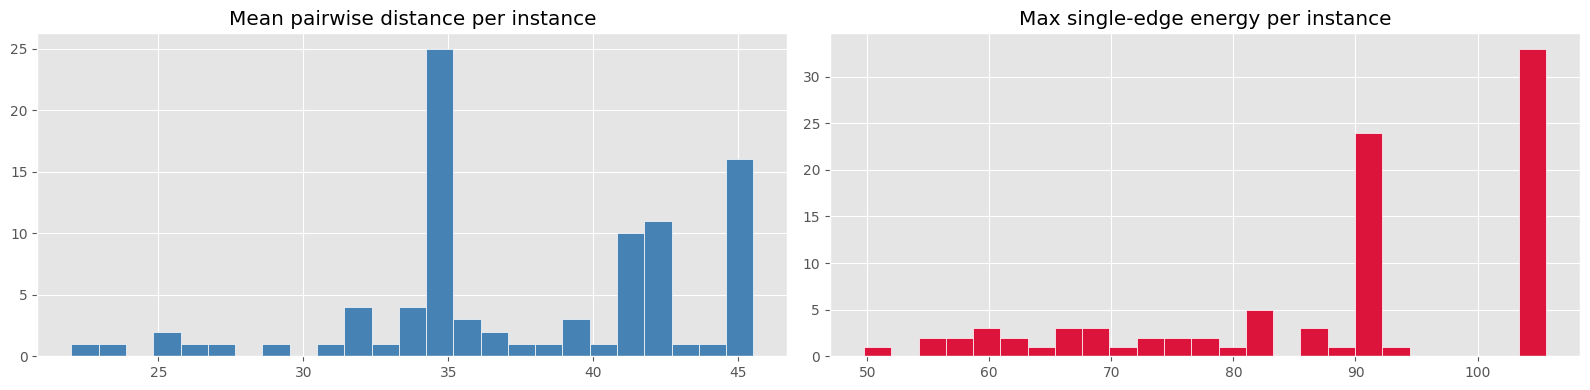

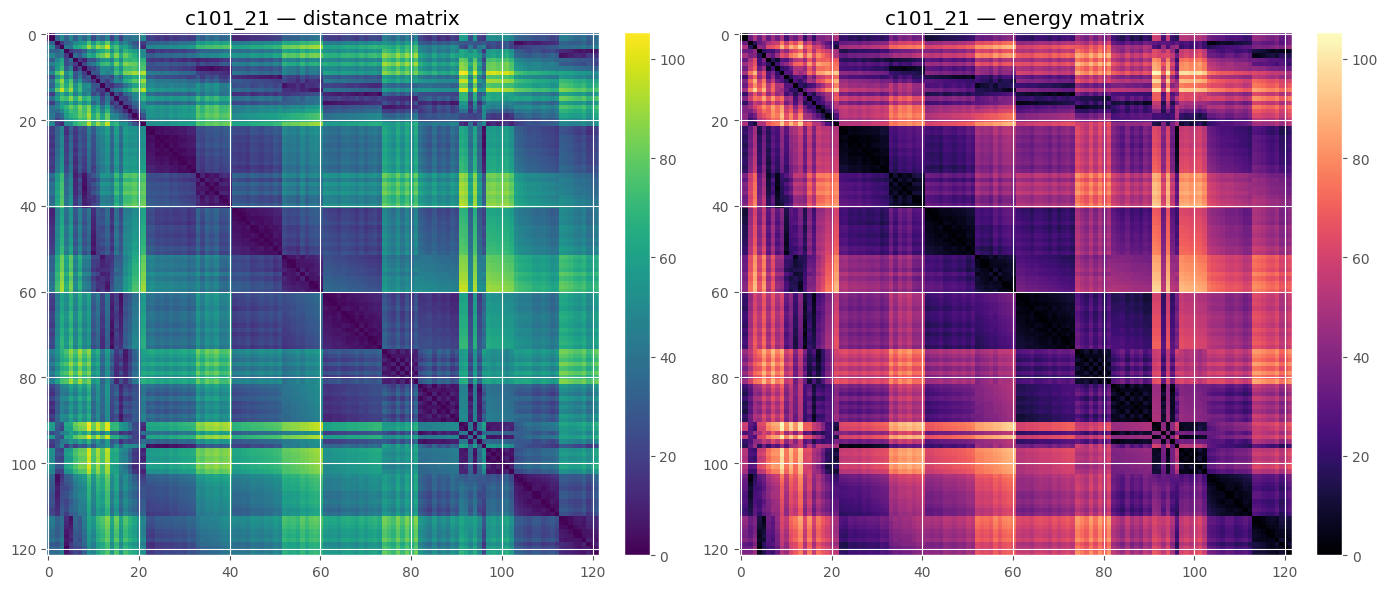

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(instance_df["mean_pair_distance"], bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("Mean pairwise distance per instance")
axes[1].hist(instance_df["max_energy_pair"], bins=25, color="crimson", edgecolor="white")
axes[1].set_title("Max single-edge energy per instance")
plt.tight_layout()
plt.show()

example = examples[0]
ex_mat = instances[example]["matrices"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(ex_mat["distance_matrix"], cmap="viridis", aspect="auto")
axes[0].set_title(f"{example} — distance matrix")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(ex_mat["energy_matrix"], cmap="magma", aspect="auto")
axes[1].set_title(f"{example} — energy matrix")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 9. Charging infrastructure

For E-VRPTW the placement of charging stations matters. We measure, for each customer, the distance to its nearest charging station (depot included, since the depot can recharge here).

Distance from each customer to nearest rechargeable node (depot or station):


,count,mean,std,min,25%,50%,75%,max
nearest_recharge_dist,5960.0,8.48,4.34,1.0,5.1,7.81,11.05,37.74


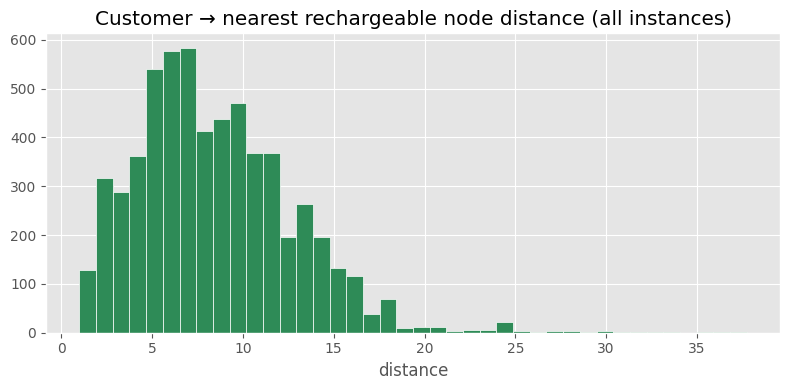

In [13]:
nearest_station_dists = []
for name, payload in instances.items():
    data = payload["json"]
    dist = payload["matrices"]["distance_matrix"]
    rec = data["index_sets"]["rechargeable_indices"]
    for c in data["index_sets"]["customer_indices"]:
        nearest = min(dist[c, r] for r in rec)
        nearest_station_dists.append({"instance": name, "nearest_recharge_dist": nearest})

nrd = pd.DataFrame(nearest_station_dists)
print("Distance from each customer to nearest rechargeable node (depot or station):")
display(nrd["nearest_recharge_dist"].describe().round(2).to_frame().T)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nrd["nearest_recharge_dist"], bins=40, color="seagreen", edgecolor="white")
ax.set_title("Customer → nearest rechargeable node distance (all instances)")
ax.set_xlabel("distance")
plt.tight_layout()
plt.show()

## 10. Reachability / feasibility pressure

For each customer `j` we compute a lower bound on the energy needed for a depot → j → nearest-recharge trip:

```
required_energy(j) = energy[depot, j] + min_r energy[j, r]
```

If `required_energy(j) > battery_capacity`, the customer cannot be served by a single direct out-and-back hop and **needs intermediate charging logic**. This is feasibility *pressure*, not infeasibility.

Instances with >=1 reachability warning: 16 / 92
Total flagged customers: 21


,instance,num_warnings,max_required_over_battery,mean_required_over_battery
0,r105_21,2,1.036,0.510
1,r103_21,2,1.036,0.510
2,r102_21,2,1.036,0.510
3,r101_21,2,1.036,0.510
4,r106_21,2,1.029,0.506
5,rc204C15,1,1.023,0.609
6,r108_21,1,1.005,0.495
7,r202C15,1,1.085,0.672
8,rc106_21,1,1.021,0.530
9,rc107_21,1,1.021,0.530



Flagged customers (need intermediate charging):


,instance,customer,required_energy,battery
0,r101_21,C64,64.41,62.14
1,r101_21,C65,62.93,62.14
2,r102_21,C64,64.41,62.14
3,r102_21,C65,62.93,62.14
4,r103_21,C64,64.41,62.14
5,r103_21,C65,62.93,62.14
6,r105_21,C64,64.41,62.14
7,r105_21,C65,62.93,62.14
8,r106_21,C64,64.41,62.60
9,r106_21,C65,62.93,62.60


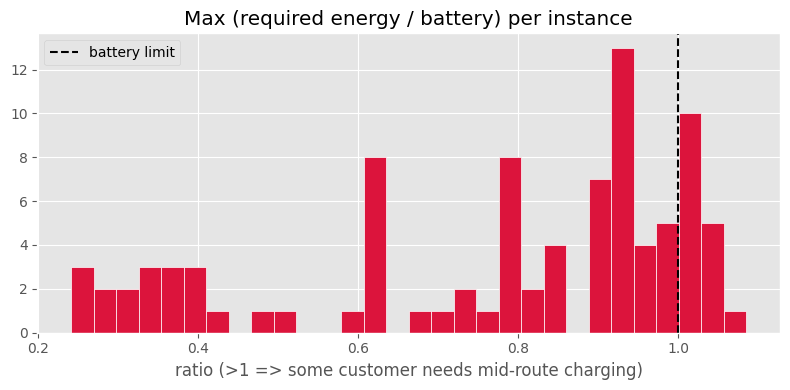

In [14]:
reach_rows = []
warn_customers = []
for name, payload in instances.items():
    data = payload["json"]
    energy = payload["matrices"]["energy_matrix"]
    battery = data["vehicle_parameters"]["battery_capacity"]
    dep = data["index_sets"]["depot_index"]
    rec = data["index_sets"]["rechargeable_indices"]
    nodes = data["nodes"]
    n_warn = 0
    ratios = []
    for c in data["index_sets"]["customer_indices"]:
        required = energy[dep, c] + min(energy[c, r] for r in rec)
        ratios.append(required / battery)
        if required > battery:
            n_warn += 1
            warn_customers.append({
                "instance": name,
                "customer": nodes[c]["string_id"],
                "required_energy": round(float(required), 2),
                "battery": battery,
            })
    reach_rows.append({
        "instance": name,
        "num_warnings": n_warn,
        "max_required_over_battery": round(float(max(ratios)), 3),
        "mean_required_over_battery": round(float(np.mean(ratios)), 3),
    })

reach_df = pd.DataFrame(reach_rows).sort_values("num_warnings", ascending=False).reset_index(drop=True)
print(f"Instances with >=1 reachability warning: {(reach_df['num_warnings'] > 0).sum()} / {len(reach_df)}")
print(f"Total flagged customers: {int(reach_df['num_warnings'].sum())}")
display(reach_df.head(12))

if warn_customers:
    print("\nFlagged customers (need intermediate charging):")
    display(pd.DataFrame(warn_customers))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reach_df["max_required_over_battery"], bins=30, color="crimson", edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", label="battery limit")
ax.set_title("Max (required energy / battery) per instance")
ax.set_xlabel("ratio (>1 => some customer needs mid-route charging)")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Feature correlations

Correlation between instance-level numeric features, to understand which difficulty drivers move together.

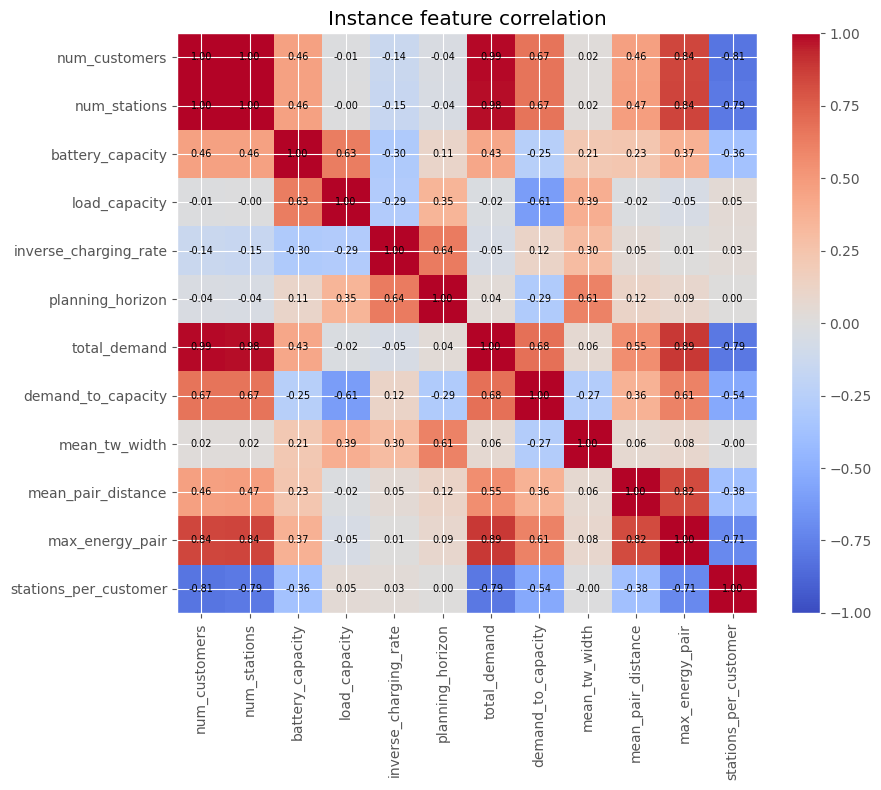

In [15]:
corr_cols = [
    "num_customers", "num_stations", "battery_capacity", "load_capacity",
    "inverse_charging_rate", "planning_horizon", "total_demand", "demand_to_capacity",
    "mean_tw_width", "mean_pair_distance", "max_energy_pair", "stations_per_customer",
]
corr = instance_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Instance feature correlation")
plt.tight_layout()
plt.show()

## 12. Instance-family comparison

Aggregated difficulty drivers per family x series.

instances  avg_customers  avg_stations  avg_battery  avg_tw_width  avg_demand_cap  avg_mean_dist
family series                                                                                                  
C      1              15          64.00         14.07        78.91        368.68            5.76          38.34
       2              14          61.43         13.71       100.73        809.25            1.59          39.42
R      1              18          70.00         15.50        63.11         81.66            5.09          32.62
       2              17          68.24         15.18       160.37        460.76            1.00          33.10
RC     1              14          61.43         13.86        78.86         88.69            5.30          43.65
       2              14          61.43         13.93       151.57        394.63            1.06          42.23

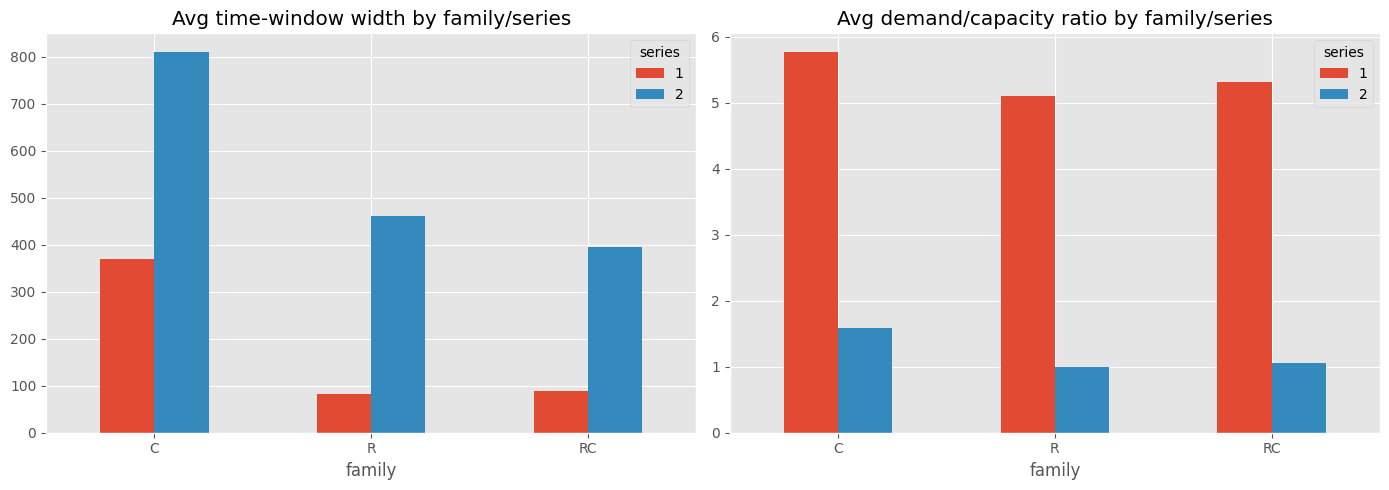

In [16]:
family_summary = (
    instance_df.groupby(["family", "series"]).agg(
        instances=("instance", "size"),
        avg_customers=("num_customers", "mean"),
        avg_stations=("num_stations", "mean"),
        avg_battery=("battery_capacity", "mean"),
        avg_tw_width=("mean_tw_width", "mean"),
        avg_demand_cap=("demand_to_capacity", "mean"),
        avg_mean_dist=("mean_pair_distance", "mean"),
    ).round(2)
)
display(family_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
piv_tw = instance_df.pivot_table(index="family", columns="series", values="mean_tw_width", aggfunc="mean")
piv_tw.plot(kind="bar", ax=axes[0])
axes[0].set_title("Avg time-window width by family/series")
axes[0].tick_params(axis="x", rotation=0)
piv_dc = instance_df.pivot_table(index="family", columns="series", values="demand_to_capacity", aggfunc="mean")
piv_dc.plot(kind="bar", ax=axes[1])
axes[1].set_title("Avg demand/capacity ratio by family/series")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 13. Key findings

Automatically generated summary of the dataset characteristics.

In [17]:
print("=" * 70)
print("E-VRPTW DATASET — KEY FINDINGS")
print("=" * 70)
print(f"Instances                 : {len(instance_df)}")
print(f"Total nodes               : {len(nodes_df)}")
print(f"Families                  : {sorted(instance_df['family'].unique())}")
print(f"Customers / instance      : {instance_df['num_customers'].min()} .. {instance_df['num_customers'].max()} (median {int(instance_df['num_customers'].median())})")
print(f"Stations / instance       : {instance_df['num_stations'].min()} .. {instance_df['num_stations'].max()}")
print(f"Battery capacity          : {instance_df['battery_capacity'].min():.2f} .. {instance_df['battery_capacity'].max():.2f}")
print(f"Load capacity (unique)    : {sorted(instance_df['load_capacity'].unique())}")
print(f"Energy consumption rate   : {sorted(instance_df['energy_consumption_rate'].unique())}")
print(f"Speed (unique)            : {sorted(instance_df['speed'].unique())}")
print(f"Planning horizon          : {instance_df['planning_horizon'].min():.0f} .. {instance_df['planning_horizon'].max():.0f}")
print(f"All depots have charging  : {bool(instance_df['depot_has_charging'].all())}")
print(f"Demand/capacity ratio     : {instance_df['demand_to_capacity'].min():.2f} .. {instance_df['demand_to_capacity'].max():.2f}")
print(f"Instances w/ reach. warns : {(reach_df['num_warnings'] > 0).sum()} ({int(reach_df['num_warnings'].sum())} customers)")
if "tw_instance_df" in globals():
    print("--- Time-window summary (see Section 5) ---")
    print(f"Mean TW width (all cust.) : {tw_df['tw_width'].mean():.1f} (median {tw_df['tw_width'].median():.1f})")
    print(f"Pct tight windows (<30)   : {100 * tw_df['tight_tw'].mean():.1f}%")
    print(f"Pct direct depot infeas.  : {100 * (1 - tw_df['direct_from_depot_feasible'].mean()):.2f}%")
    print(f"Mean chain-feasible rate  : {tw_instance_df['chain_feasible_rate'].mean():.3f}")
    print("Hardest TW family×series (lowest chain rate):")
    hardest = tw_instance_df.groupby(["family", "series"])["chain_feasible_rate"].mean().sort_values().head(3)
    for (fam, ser), val in hardest.items():
        print(f"  {fam}{ser}: chain_rate={val:.3f}")
print("=" * 70)

display(instance_df.describe().round(2))

E-VRPTW DATASET — KEY FINDINGS
Instances                 : 92
Total nodes               : 7381
Families                  : ['C', 'R', 'RC']
Customers / instance      : 5 .. 100 (median 100)
Stations / instance       : 2 .. 21
Battery capacity          : 60.63 .. 273.13
Load capacity (unique)    : [np.float64(200.0), np.float64(700.0), np.float64(1000.0)]
Energy consumption rate   : [np.float64(1.0)]
Speed (unique)            : [np.float64(1.0)]
Planning horizon          : 230 .. 3390
All depots have charging  : True
Demand/capacity ratio     : 0.06 .. 9.05
Instances w/ reach. warns : 16 (21 customers)


,series,num_nodes,num_customers,num_stations,battery_capacity,load_capacity,energy_consumption_rate,inverse_charging_rate,speed,planning_horizon,total_demand,mean_demand,max_demand,demand_to_capacity,mean_tw_width,mean_service_time,mean_pair_distance,max_pair_distance,max_energy_pair,battery_vs_maxedge,stations_per_customer
count,92.00,92.00,92.00,92.00,92.00,92.00,92.0,92.00,92.0,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00
mean,1.49,80.23,64.78,14.45,105.24,545.65,1.0,1.22,1.0,1129.78,1063.35,16.62,39.50,3.33,357.92,35.22,37.82,89.00,89.00,1.18,0.31
std,0.50,52.48,44.24,8.25,58.35,368.37,0.0,1.33,0.0,1037.94,735.68,2.65,7.64,3.42,379.65,37.37,5.70,16.30,16.30,0.57,0.17
min,1.00,8.00,5.00,2.00,60.63,200.00,1.0,0.11,1.0,230.00,58.00,10.90,20.00,0.06,10.00,10.00,22.00,49.73,49.73,0.68,0.20
25%,1.00,16.00,10.00,4.75,67.14,200.00,1.0,0.38,1.0,240.00,188.50,14.58,40.00,0.66,106.93,10.00,34.70,77.69,77.69,0.76,0.21
50%,1.00,122.00,100.00,21.00,77.75,200.00,1.0,0.48,1.0,980.00,1458.00,17.24,40.00,1.46,232.50,10.00,36.76,91.83,91.83,0.97,0.21
75%,2.00,122.00,100.00,21.00,117.86,1000.00,1.0,2.29,1.0,1236.00,1724.00,18.10,41.00,7.29,530.22,90.00,41.92,105.31,105.31,1.22,0.40
max,2.00,122.00,100.00,21.00,273.13,1000.00,1.0,3.47,1.0,3390.00,1810.00,29.00,50.00,9.05,2492.74,90.00,45.52,105.60,105.60,2.91,0.80
